In [ ]:
import torch
print(f'pytorch version: {torch.__version__}')
print(f'cuda version: {torch.version.cuda}')
if torch.cuda.is_available():
    print(f'cuda device name: {torch.cuda.get_device_name(0)}')
print(f'cuda available: {torch.cuda.is_available()}')

pytorch version: 2.11.0+cu128
cuda version: 12.8
cuda device name: Tesla T4
cuda available: True


In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cull8

Looking in indexes: https://download.pytorch.org/whl/cull8
INFO: pip is looking at multiple versions of torch to determine which version is compatible with other requirements. This could take a while.
ERROR: Could not find a version that satisfies the requirement setuptools<82 (from torch) (from versions: none)
ERROR: No matching distribution found for setuptools<82


In [ ]:
# Install a specific version of tokenizers known to work with transformers 4.30.2
!pip install tokenizers==0.12.1

  Using cached tokenizers-0.12.1.tar.gz (220 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> No available output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tokenizers
Failed to build tokenizers
error: failed-wheel-build-for-install

× Failed to build installable wheels for some pyproject.toml based projects
╰─> tokenizers


In [ ]:
!pip install diffusers==0.21.0 transformers==4.30.2 accelerate==0.20.3

  Using cached diffusers-0.21.0-py3-none-any.whl
  Using cached transformers-4.30.2-py3-none-any.whl.metadata (113 kB)
  Using cached accelerate-0.20.3-py3-none-any.whl.metadata (17 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached tokenizers-0.13.3.tar.gz (314 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Using cached transformers-4.30.2-py3-none-any.whl (7.2 MB)
Using cached accelerate-0.20.3-py3-none-any.whl (227 kB)
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 33.8 MB/s  0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> No available output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tokenizers
Failed t

In [ ]:
import warnings
warnings.filterwarnings('ignore')
!pip install --upgrade pip setuptools

In [ ]:
!pip install safetensors==0.3.1 xformers==0.0.20 pillow==9.5.0

  Using cached safetensors-0.3.1.tar.gz (34 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached xformers-0.0.20.tar.gz (7.6 MB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> No available output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
ERROR: Failed to build 'xformers' when getting requirements to build wheel


In [ ]:
!pip install numpy==1.24.4 matplotlib==3.7.2 gradio==4.0.0

  Using cached numpy-1.24.4.tar.gz (10.9 MB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> No available output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
ERROR: Failed to build 'numpy' when getting requirements to build wheel


In [ ]:
!pip install gradio

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import torch
import torch.nn.functional as f

In [ ]:
from diffusers import StableDiffusionPipeline
import gradio as gr
from PIL import Image
import torch.nn.functional as F
from torch import autocast
import numpy as np
from PIL import Image
import os,time,gc
from typing import List,Tuple,Optional
from datetime import datetime
from diffusers import (
    StableDiffusionPipeline,
    DDIMScheduler,
    DPMSolverMultistepScheduler,
    EulerDiscreteScheduler,
    EulerAncestralDiscreteScheduler,
    DPMSolverMultistepScheduler,
    LMSDiscreteScheduler,
)



Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
print(f'Pytorch version: {torch.__version__}')
print(f'cuda available: {torch.cuda.is_available()}')
print(f'GPU available: {torch.cuda.is_available() if torch.cuda.is_available() else "No GPU"}')

Pytorch version: 2.11.0+cu128
cuda available: True
GPU available: True


In [ ]:
# NOTE: get_memory_usage() used to sit here as its own, disconnected cell,
# never attached to the StableDiffusionGenerator class below. Any UI calling
# self.generator.get_memory_usage() (e.g. the "Initialize Model" button in
# the Task 1 UI) would fail with:
#   AttributeError: 'StableDiffusionGenerator' object has no attribute 'get_memory_usage'
# The method has been moved into the class in the next cell, where it belongs.


In [ ]:
from __future__ import annotations

import os
import gc
import time
import torch

from diffusers import (
    StableDiffusionPipeline,
    DDIMScheduler,
    DPMSolverMultistepScheduler,
    EulerDiscreteScheduler,
    EulerAncestralDiscreteScheduler,
    LMSDiscreteScheduler,
)


class StableDiffusionGenerator:

    def __init__(
        self,
        model_id="stable-diffusion-v1-5/stable-diffusion-v1-5",
        device="auto"
    ):

        self.device = self._setup_device(device)

        self.dtype = (
            torch.float16
            if self.device.type == "cuda"
            else torch.float32
        )

        self.lora_loaded = False

        self.pipe = StableDiffusionPipeline.from_pretrained(
            model_id,
            torch_dtype=self.dtype,
            safety_checker=None
        ).to(self.device)

        if self.device.type == "cuda":
            self.pipe.enable_attention_slicing()

        self.tokenizer = self.pipe.tokenizer
        self.text_encoder = self.pipe.text_encoder
        self.text_encoder.eval()

        self.current_scheduler = "euler_a"

        print(f"Initializing Stable Diffusion on {self.device}")
        print("Task 1 LoRA: OFF")
        print("Task 3 text tokenizer + encoder: ON")

    def _setup_device(self, device):

        if device == "auto":
            return torch.device(
                "cuda" if torch.cuda.is_available()
                else "cpu"
            )

        return torch.device(device)

    def tokenize_text(self, text):

        tokens = self.tokenizer(
            text,
            padding="max_length",
            max_length=self.tokenizer.model_max_length,
            truncation=True,
            return_tensors="pt"
        )

        input_ids = tokens.input_ids.to(self.device)
        attention_mask = tokens.attention_mask.to(self.device)

        with torch.no_grad():

            output = self.text_encoder(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

        return input_ids, output.last_hidden_state

    def set_scheduler(self, scheduler_name):

        scheduler_map = {
            "euler_a": EulerAncestralDiscreteScheduler,
            "euler": EulerDiscreteScheduler,
            "ddim": DDIMScheduler,
            "dpm_solver": DPMSolverMultistepScheduler,
            "lms": LMSDiscreteScheduler
        }

        if scheduler_name in scheduler_map:

            self.pipe.scheduler = (
                scheduler_map[scheduler_name]
                .from_config(
                    self.pipe.scheduler.config
                )
            )

    def generate_image(
        self,
        prompt,
        negative_prompt="",
        width=512,
        height=512,
        num_inference_steps=30,
        guidance_scale=7.5,
        seed=None,
        scheduler="euler_a"
    ):

        self.set_scheduler(scheduler)

        if seed is None:
            seed = torch.randint(
                0,
                2**32,
                (1,)
            ).item()

        generator = torch.Generator(
            device=self.device
        ).manual_seed(seed)

        start_time = time.time()

        negative_text = (
            negative_prompt.strip()
            if negative_prompt.strip()
            else "blurry, low quality, distorted"
        )

        encoded = self.pipe.encode_prompt(
            prompt=prompt,
            device=self.device,
            num_images_per_prompt=1,
            do_classifier_free_guidance=True,
            negative_prompt=negative_text
        )

        if isinstance(encoded, tuple):
            # encode_prompt() returns a plain 2-tuple: (prompt_embeds, negative_prompt_embeds).
            # This used to read encoded[2], which doesn't exist (IndexError) and made every
            # single generation fail.
            prompt_embeds = encoded[0]
            negative_prompt_embeds = encoded[1]
        else:
            prompt_embeds = encoded.prompt_embeds
            negative_prompt_embeds = encoded.negative_prompt_embeds

        prompt_embeds = prompt_embeds.to(
            device=self.device,
            dtype=self.pipe.unet.dtype
        )

        negative_prompt_embeds = negative_prompt_embeds.to(
            device=self.device,
            dtype=self.pipe.unet.dtype
        )

        tokenized = self.tokenizer(
            prompt,
            padding="max_length",
            max_length=self.tokenizer.model_max_length,
            truncation=True,
            return_tensors="pt"
        )

        with torch.inference_mode():

            result = self.pipe(
                prompt_embeds=prompt_embeds,
                negative_prompt_embeds=negative_prompt_embeds,
                width=int(width),
                height=int(height),
                num_inference_steps=int(num_inference_steps),
                guidance_scale=float(guidance_scale),
                generator=generator
            )

        generation_time = time.time() - start_time

        return result.images[0], {
            "seed": seed,
            "time": generation_time,
            "token_shape": tuple(tokenized.input_ids.shape),
            "embedding_shape": tuple(prompt_embeds.shape),
            "lora_loaded": self.lora_loaded
        }

    def get_memory_usage(self):

        if self.device.type == "cuda":

            return {
                "allocated":
                torch.cuda.memory_allocated(0) / 1024**3
            }

        return {
            "status": "CPU mode"
        }


In [ ]:
import gradio as gr


class StableDiffusionUI:

    def __init__(self):

        self.generator = None
        self.gallery_images = []
        self.generation_history = []

    def initialize_generator(
        self,
        model_choice,
        device_choice
    ):

        try:

            model_map = {
                "Stable Diffusion 1.5":
                    "stable-diffusion-v1-5/stable-diffusion-v1-5"
            }

            device_map = {
                "Auto (Recommended)": "auto",
                "GPU (CUDA)": "cuda",
                "CPU (Slower)": "cpu"
            }

            model_id = model_map[model_choice]
            device_id = device_map[device_choice]

            self.generator = StableDiffusionGenerator(
                model_id=model_id,
                device=device_id
            )

            memory = self.generator.get_memory_usage()

            if self.generator.lora_loaded:
                lora_status = "Task 1 LoRA: Loaded"
            else:
                lora_status = (
                    "Task 1 LoRA: Not available "
                    "(Base model active)"
                )

            return (
                "Model initialized successfully!\n"
                f"{lora_status}\n"
                f"Memory: {memory}"
            )

        except Exception as e:
            return f"Error: {str(e)}"

    def text_to_image(
        self,
        prompt,
        negative_prompt,
        width,
        height,
        steps,
        guidance,
        seed,
        scheduler,
        save_image
    ):

        if self.generator is None:
            return (
                None,
                "Initialize the model first.",
                "",
                []
            )

        if not prompt.strip():
            return (
                None,
                "Please enter a prompt.",
                "",
                self.gallery_images
            )

        try:

            actual_seed = (
                None
                if int(seed) == -1
                else int(seed)
            )

            image, metadata = self.generator.generate_image(
                prompt=prompt,
                negative_prompt=negative_prompt,
                width=int(width),
                height=int(height),
                num_inference_steps=int(steps),
                guidance_scale=float(guidance),
                seed=actual_seed,
                scheduler=scheduler
            )

            saved_path = ""

            if save_image:

                timestamp = int(time.time())

                saved_path = (
                    f"/content/generated_{timestamp}.png"
                )

                image.save(saved_path)

            self.gallery_images.append(image)

            if len(self.gallery_images) > 10:
                self.gallery_images = self.gallery_images[-10:]

            info = f"""
T

Prompt:
{prompt}

Tokenized Shape:
{metadata["token_shape"]}

Text Embedding Shape:
{metadata["embedding_shape"]}

Scheduler:
{scheduler}

Seed:
{metadata["seed"]}

Generation Time:
{metadata["time"]:.2f} seconds

LoRA:
{"Loaded" if metadata["lora_loaded"] else "Not loaded"}

Device:
{self.generator.device}
"""

            return (
                image,
                info,
                saved_path,
                self.gallery_images
            )

        except Exception as e:

            return (
                None,
                f"Generation failed: {str(e)}",
                "",
                self.gallery_images
            )

    def generate_cgan(self, shape_label):

        try:

            image = generate_shape(shape_label)

            image = (
                image * 255
            ).astype(np.uint8)

            return Image.fromarray(image)

        except Exception as e:

            print(e)

            return None

    def show_scheduler_info(self, scheduler):

        info = {
            "euler_a": "Euler Ancestral - Fast and creative",
            "euler": "Euler - Consistent",
            "ddim": "DDIM - Classic",
            "dpm_solver": "DPM Solver - High quality",
            "lms": "LMS - Stable"
        }

        return info.get(scheduler, "")

    def create_interface(self):

        with gr.Blocks(
            title="AI Image Generation Suite"
        ) as interface:

            gr.Markdown(
                """
# AI Image Generation Suite

Task 1 + Task 2 + Task 3

Text → Tokenization → Embeddings → Image
"""
            )

            with gr.Tab("Task 1 + Task 3: Text to Image"):

                with gr.Row():

                    with gr.Column():

                        model_choice = gr.Dropdown(
                            choices=[
                                "Stable Diffusion 1.5"
                            ],
                            value="Stable Diffusion 1.5",
                            label="Model"
                        )

                        device_choice = gr.Dropdown(
                            choices=[
                                "Auto (Recommended)",
                                "GPU (CUDA)",
                                "CPU (Slower)"
                            ],
                            value="GPU (CUDA)",
                            label="Device"
                        )

                        initialize_btn = gr.Button(
                            "Initialize Model",
                            variant="primary"
                        )

                        status = gr.Textbox(
                            label="Model Status",
                            lines=4
                        )

                    with gr.Column():

                        prompt = gr.Textbox(
                            label="Text Description",
                            placeholder="Describe the image...",
                            lines=4
                        )

                        negative_prompt = gr.Textbox(
                            label="Negative Prompt",
                            value="blurry, low quality, distorted",
                            lines=2
                        )

            with gr.Accordion(
                "Generation Settings",
                open=False
            ):

                width = gr.Slider(
                    256,
                    1024,
                    512,
                    step=64,
                    label="Width"
                )

                height = gr.Slider(
                    256,
                    1024,
                    512,
                    step=64,
                    label="Height"
                )

                steps = gr.Slider(
                    10,
                    50,
                    25,
                    step=1,
                    label="Inference Steps"
                )

                guidance = gr.Slider(
                    1,
                    15,
                    7.5,
                    step=0.5,
                    label="Guidance Scale"
                )

                scheduler = gr.Dropdown(
                    choices=[
                        "euler_a",
                        "euler",
                        "ddim",
                        "dpm_solver",
                        "lms"
                    ],
                    value="euler_a",
                    label="Scheduler"
                )

                scheduler_info = gr.Textbox(
                    label="Scheduler Information"
                )

                seed = gr.Number(
                    value=-1,
                    label="Seed (-1 = Random)"
                )

                save_image = gr.Checkbox(
                    value=True,
                    label="Save Image"
                )

            generate_btn = gr.Button(
                "Generate Image",
                variant="primary"
            )

            output_image = gr.Image(
                label="Generated Image",
                type="pil"
            )

            generation_info = gr.Textbox(
                label="Generation Details",
                lines=12
            )

            save_path = gr.Textbox(
                label="Saved Image"
            )

            gallery = gr.Gallery(
                label="Recent Images",
                columns=4,
                rows=2
            )

            with gr.Tab("Task 2: Conditional GAN"):

                shape_input = gr.Dropdown(
                    choices=[
                        "circle",
                        "square"
                    ],
                    value="circle",
                    label="Shape Category"
                )

                cgan_btn = gr.Button(
                    "Generate Shape",
                    variant="primary"
                )

                cgan_output = gr.Image(
                    label="Generated CGAN Shape",
                    type="pil"
                )

            with gr.Tab("About Tasks"):

                gr.Markdown(
                    """

"""
                )

            initialize_btn.click(
                fn=self.initialize_generator,
                inputs=[
                    model_choice,
                    device_choice
                ],
                outputs=status
            )

            scheduler.change(
                fn=self.show_scheduler_info,
                inputs=scheduler,
                outputs=scheduler_info
            )

            generate_btn.click(
                fn=self.text_to_image,
                inputs=[
                    prompt,
                    negative_prompt,
                    width,
                    height,
                    steps,
                    guidance,
                    seed,
                    scheduler,
                    save_image
                ],
                outputs=[
                    output_image,
                    generation_info,
                    save_path,
                    gallery
                ]
            )

            cgan_btn.click(
                fn=self.generate_cgan,
                inputs=shape_input,
                outputs=cgan_output
            )

        return interface

In [ ]:
# Standalone Gradio launch disabled.
# The project is launched once in the final combined Gradio app (Task 1-6).


In [ ]:
import os

print("LoRA exists:", os.path.exists("/content/book_cover_lora"))
!ls -lah /content

LoRA exists: False
total 20K
drwxr-xr-x 1 root root 4.0K Aug 17 14:05 .
drwxr-xr-x 1 root root 4.0K Aug 17 13:59 ..
drwxr-xr-x 4 root root 4.0K Aug 10 13:31 .config
drwxr-xr-x 2 root root 4.0K Aug 17 14:05 .gradio
drwxr-xr-x 1 root root 4.0K Aug 10 13:31 sample_data


## **TASK 1**

In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


CUDA available: True
GPU: Tesla T4


In [ ]:
!pip install -q diffusers transformers accelerate peft datasets bitsandbytes ftfy

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


In [ ]:
import torch

print("GPU:", torch.cuda.get_device_name(0))
print("CUDA:", torch.cuda.is_available())

GPU: Tesla T4
CUDA: True


In [ ]:
import os

dataset_dir = "/content/custom_dataset"
os.makedirs(dataset_dir, exist_ok=True)

print("Dataset folder:", dataset_dir)

Dataset folder: /content/custom_dataset


In [ ]:
from datasets import load_dataset

ds = load_dataset(
    "biglam/british-library-book-images",
    data_dir="covers",
    split="train",
    streaming=True
)

print(ds)
print(next(iter(ds)))

README.md:   0%|          | 0.00/11.1k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/104 [00:00<?, ?it/s]

In [ ]:
import os
import io
from PIL import Image

output_dir = "/content/custom_dataset"
os.makedirs(output_dir, exist_ok=True)

count = 0
max_images = 20

for item in ds:
    # The 'image' field in `item` is a dictionary containing 'bytes'
    image_bytes = item["image"]["bytes"]
    # Load the image from bytes into a PIL Image object
    image = Image.open(io.BytesIO(image_bytes))

    if image.mode != "RGB":
        image = image.convert("RGB")

    image_path = os.path.join(output_dir, f"cover_{count+1:03d}.jpg")
    image.save(image_path, quality=95)

    count += 1

    if count >= max_images:
        break

print(f"Saved {count} images to {output_dir}")

Saved 20 images to /content/custom_dataset


In [ ]:
import os
import json

dataset_dir = "/content/custom_dataset"
os.makedirs(dataset_dir, exist_ok=True) # Ensure the directory exists

# Debug: Print directory contents to verify if files are present
print("Contents of dataset_dir before filtering:", os.listdir(dataset_dir))

metadata = []

image_files = sorted([
    f for f in os.listdir(dataset_dir)
    if f.lower().endswith((
        ".jpg", ".jpeg", ".png", ".webp"))
])

for filename in image_files:
    caption = "a vintage historical British book cover, detailed artwork, decorative design"

    metadata.append({
        "file_name": filename,
        "text": caption
    })

metadata_path = os.path.join(dataset_dir, "metadata.jsonl")

with open(metadata_path, "w", encoding="utf-8") as f:
    for item in metadata:
        f.write(json.dumps(item) + "\n")

print("Images:", len(image_files))
print("Metadata created:", metadata_path)

# Check if metadata is not empty before accessing metadata[0]
if metadata:
    print("Example:", metadata[0])
else:
    print("No metadata entries were created because no images were found.")

Contents of dataset_dir before filtering: ['cover_014.jpg', 'cover_001.jpg', 'cover_017.jpg', 'cover_011.jpg', 'cover_008.jpg', 'cover_020.jpg', 'cover_013.jpg', 'cover_005.jpg', 'cover_016.jpg', 'cover_012.jpg', 'cover_004.jpg', 'cover_002.jpg', 'cover_006.jpg', 'cover_009.jpg', 'cover_007.jpg', 'cover_003.jpg', 'cover_010.jpg', 'cover_015.jpg', 'cover_018.jpg', 'cover_019.jpg']
Images: 20
Metadata created: /content/custom_dataset/metadata.jsonl
Example: {'file_name': 'cover_001.jpg', 'text': 'a vintage historical British book cover, detailed artwork, decorative design'}


In [ ]:
from datasets import load_dataset

train_data = load_dataset(
    "imagefolder",
    data_dir="/content/custom_dataset",
    split="train"
)

print(train_data)
print(train_data.column_names)

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['image', 'text'],
    num_rows: 20
})
['image', 'text']


In [ ]:
!pip install -q -U diffusers transformers accelerate peft datasets bitsandbytes

In [ ]:
!git clone -q https://github.com/huggingface/diffusers.git

In [ ]:
%cd /content/diffusers
!pip install -q -r examples/text_to_image/requirements.txt

/content/diffusers


In [ ]:
!pip install -U "torchao>=0.16.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 84.1 MB/s  0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [ ]:
import importlib.metadata as md

print("torch:", md.version("torch"))
print("torchao:", md.version("torchao"))
print("peft:", md.version("peft"))

torch: 2.11.0+cu128
torchao: 0.18.0
peft: 0.20.0


In [ ]:
!accelerate launch examples/text_to_image/train_text_to_image_lora.py \
  --pretrained_model_name_or_path="stable-diffusion-v1-5/stable-diffusion-v1-5" \
  --train_data_dir="/content/custom_dataset" \
  --image_column="image" \
  --caption_column="text" \
  --resolution=512 \
  --random_flip \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --gradient_checkpointing \
  --mixed_precision="fp16" \
  --use_8bit_adam \
  --learning_rate=1e-4 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --max_train_steps=800 \
  --checkpointing_steps=200 \
  --rank=4 \
  --output_dir="/content/book_cover_lora" \
  --seed=42

In [ ]:
%cd /content/diffusers

!pip install -q -e ".[torch]"

In [ ]:
import diffusers
import importlib.metadata

print("Diffusers version:", importlib.metadata.version('diffusers'))
print("Diffusers path:", diffusers.__file__)

In [ ]:
import os

base = "/content/book_cover_lora/checkpoint-600"

print("Exists:", os.path.exists(base))

if os.path.exists(base):
    print("\nFiles inside checkpoint-600:")
    for root, dirs, files in os.walk(base):
        print("\n", root)
        for f in files:
            print("   ", f)
else:
    print("checkpoint-600 does NOT exist")

In [ ]:
import os

print("custom_dataset:", os.path.exists("/content/custom_dataset"))
print("diffusers:", os.path.exists("/content/diffusers"))

!ls -lah /content

In [ ]:
!find /content/book_cover_lora -maxdepth 2 -type f | sort

In [ ]:
import os

print("Dataset exists:", os.path.exists("/content/custom_dataset"))
print("Diffusers exists:", os.path.exists("/content/diffusers"))

!ls -lah /content

In [ ]:
import json
import os

dataset_dir = "/content/custom_dataset"
metadata_path = os.path.join(dataset_dir, "metadata.jsonl")

image_files = sorted([
    f for f in os.listdir(dataset_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
])

print("Images found:", len(image_files))

with open(metadata_path, "w", encoding="utf-8") as f:
    for filename in image_files:
        record = {
            "file_name": filename,
            "text": "a vintage historical British book cover, ornate decorative artwork, detailed illustration, antique book design"
        }
        f.write(json.dumps(record) + "\n")

print("✅ metadata.jsonl created")

In [ ]:
from datasets import load_dataset

train_data = load_dataset(
    "imagefolder",
    data_dir="/content/custom_dataset",
    split="train"
)

print(train_data)
print(train_data.column_names)

In [ ]:
import importlib.metadata as md

print("torchao:", md.version("torchao"))
print("peft:", md.version("peft"))

In [ ]:
%cd /content/diffusers

!accelerate launch \
  --mixed_precision="fp16" \
  examples/text_to_image/train_text_to_image_lora.py \
  --pretrained_model_name_or_path="stable-diffusion-v1-5/stable-diffusion-v1-5" \
  --train_data_dir="/content/custom_dataset" \
  --image_column="image" \
  --caption_column="text" \
  --resolution=512 \
  --random_flip \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --gradient_checkpointing \
  --use_8bit_adam \
  --learning_rate=1e-4 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --max_train_steps=400 \
  --checkpointing_steps=100 \
  --rank=4 \
  --output_dir="/content/book_cover_lora" \
  --seed=42

In [ ]:
!find /content/book_cover_lora -maxdepth 2 -type f | sort

In [ ]:
import os

print("Folder exists:", os.path.exists("/content/book_cover_lora"))

In [ ]:
!ls -lah /content/book_cover_lora

In [ ]:
!find /content/book_cover_lora -maxdepth 3 -type f

In [ ]:
!find /content/book_cover_lora -maxdepth 2 -type d -print

In [ ]:
!ls -lah /content/book_cover_lora/logs/text2image-fine-tune

In [ ]:
import os

images = [
    f for f in os.listdir("/content/custom_dataset")
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
]

print("Images:", len(images))
print("First 5:", images[:5])
print("Metadata exists:", os.path.exists("/content/custom_dataset/metadata.jsonl"))

In [ ]:
%cd /content/diffusers

!rm -rf /content/book_cover_lora

!accelerate launch \
  examples/text_to_image/train_text_to_image_lora.py \
  --pretrained_model_name_or_path="stable-diffusion-v1-5/stable-diffusion-v1-5" \
  --train_data_dir="/content/custom_dataset" \
  --image_column="image" \
  --caption_column="text" \
  --resolution=512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --gradient_checkpointing \
  --learning_rate=1e-4 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --max_train_steps=100 \
  --checkpointing_steps=50 \
  --rank=4 \
  --output_dir="/content/book_cover_lora" \
  --seed=42

In [ ]:
!find /content/book_cover_lora -maxdepth 3 -type f | sort

In [ ]:
!find /content/book_cover_lora -maxdepth 3 -type f | sort

In [ ]:
import sys
import os

sys.path.insert(0, "/content/diffusers/src")


for name in list(sys.modules):
    if name == "diffusers" or name.startswith("diffusers."):
        del sys.modules[name]

from diffusers import StableDiffusionPipeline

print(" StableDiffusionPipeline imported successfully")
print("Diffusers location:", sys.path[0])

In [ ]:
import torch
from diffusers import StableDiffusionPipeline

BASE_MODEL = "stable-diffusion-v1-5/stable-diffusion-v1-5"
LORA_DIR = "/content/book_cover_lora"

pipe = StableDiffusionPipeline.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float32,
    safety_checker=None
)

pipe = pipe.to("cuda")

pipe.load_lora_weights(
    LORA_DIR,
    weight_name="pytorch_lora_weights.safetensors"
)

print(" Base model loaded")
print(" Fine-tuned LoRA loaded")

In [ ]:
import os
from IPython.display import display

prompt = """
a vintage British book cover, ornate decorative artwork,
historical illustration, antique paper texture,
elegant detailed design
"""

try:
    result = pipe(
        prompt,
        num_inference_steps=30,
        guidance_scale=7.5
    )

    image = result.images[0]

    print(" Image generated")
    print("Image size:", image.size)

    display(image)

    save_path = "/content/fine_tuned_book_cover.png"
    image.save(save_path)

    print("Saved at:", save_path)
    print("File exists:", os.path.exists(save_path))
    print("File size:", os.path.getsize(save_path), "bytes")

except Exception as e:
    print(" Error:", type(e).__name__)
    print(e)

In [ ]:
import os

print(os.path.exists("/content/fine_tuned_book_cover.png"))

In [ ]:
pipe.load_lora_weights(
    "/content/book_cover_lora",
    weight_name="pytorch_lora_weights.safetensors"
)

# TASK **2**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
IMG_SIZE = 64
NUM_SAMPLES = 2000
NUM_CLASSES = 2
LATENT_DIM = 100
BATCH_SIZE = 64
X = []
y = []

yy, xx = np.ogrid[:IMG_SIZE, :IMG_SIZE]

cx = IMG_SIZE // 2
cy = IMG_SIZE // 2
size = 16

for _ in range(NUM_SAMPLES):

    img = np.zeros(
        (IMG_SIZE, IMG_SIZE),
        dtype=np.float32
    )

    label = np.random.randint(0, 2)

    if label == 0:
        mask = (
            (xx - cx) ** 2 +
            (yy - cy) ** 2
            <= size ** 2
        )
    else:
        mask = (
            (xx >= cx - size) &
            (xx <= cx + size) &
            (yy >= cy - size) &
            (yy <= cy + size)
        )

    img[mask] = 1.0

    X.append(img)
    y.append(label)

X = np.array(X, dtype=np.float32)
X = X[..., np.newaxis]

y = np.array(y, dtype=np.int32)

print("Images:", X.shape)
print("Labels:", y.shape)
print("Circles:", np.sum(y == 0))
print("Squares:", np.sum(y == 1))

Images: (2000, 64, 64, 1)
Labels: (2000,)
Circles: 992
Squares: 1008


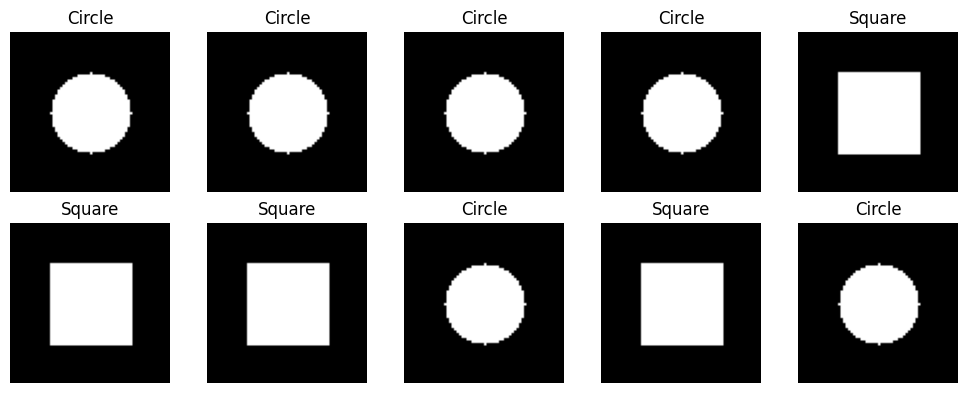

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax in axes.flat:

    idx = np.random.randint(0, len(X))

    ax.imshow(
        X[idx].squeeze(),
        cmap="gray"
    )

    ax.set_title(
        "Circle"
        if y[idx] == 0
        else "Square"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
dataset = tf.data.Dataset.from_tensor_slices(
    (X, y)
)

dataset = (
    dataset
    .shuffle(len(X))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Dataset ready")

def build_generator():

    noise_input = layers.Input(
        shape=(LATENT_DIM,),
        name="noise"
    )

    label_input = layers.Input(
        shape=(1,),
        dtype=tf.int32,
        name="label"
    )

    label_embedding = layers.Embedding(
        NUM_CLASSES,
        20
    )(label_input)

    label_embedding = layers.Flatten()(
        label_embedding
    )

    x = layers.Concatenate()([
        noise_input,
        label_embedding
    ])

    x = layers.Dense(
        8 * 8 * 256,
        use_bias=False
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Reshape(
        (8, 8, 256)
    )(x)

    x = layers.Conv2DTranspose(
        128,
        4,
        strides=2,
        padding="same",
        use_bias=False
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2DTranspose(
        64,
        4,
        strides=2,
        padding="same",
        use_bias=False
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2DTranspose(
        32,
        4,
        strides=2,
        padding="same",
        use_bias=False
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    output = layers.Conv2D(
        1,
        3,
        padding="same",
        activation="sigmoid"
    )(x)

    return tf.keras.Model(
        [noise_input, label_input],
        output,
        name="CGAN_Generator"
    )


generator = build_generator()

generator.summary()


Dataset ready


Model: "CGAN_Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 1, 20)     │         40 │ label[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise (InputLayer)  │ (None, 100)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 20)        │          0 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 120)       │          0 │ noise[0][0],      │
│ (Concatenate)       │                   │            │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 16384)     │  1,966,080 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16384)     │     65,536 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_11      │ (None, 16384)     │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 8, 8, 256) │          0 │ leaky_re_lu_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_6  │ (None, 16, 16,    │    524,288 │ reshape_3[0][0]   │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_12      │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_7  │ (None, 32, 32,    │    131,072 │ leaky_re_lu_12[0… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_13      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_8  │ (None, 64, 64,    │     32,768 │ leaky_re_lu_13[0… │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_14      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,720,969 (10.38 MB)

 Trainable params: 2,687,753 (10.25 MB)

 Non-trainable params: 33,216 (129.75 KB)

In [ ]:
def build_discriminator():

    image_input = layers.Input(
        shape=(IMG_SIZE, IMG_SIZE, 1),
        name="image"
    )

    label_input = layers.Input(
        shape=(1,),
        dtype=tf.int32,
        name="label"
    )

    label_embedding = layers.Embedding(
        NUM_CLASSES,
        IMG_SIZE * IMG_SIZE
    )(label_input)

    label_embedding = layers.Flatten()(
        label_embedding
    )

    label_embedding = layers.Reshape(
        (IMG_SIZE, IMG_SIZE, 1)
    )(label_embedding)

    x = layers.Concatenate()([
        image_input,
        label_embedding
    ])

    x = layers.Conv2D(
        64,
        4,
        strides=2,
        padding="same"
    )(x)

    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(
        128,
        4,
        strides=2,
        padding="same"
    )(x)

    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(
        256,
        4,
        strides=2,
        padding="same"
    )(x)

    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Flatten()(x)

    output = layers.Dense(
        1,
        activation="sigmoid"
    )(x)

    return tf.keras.Model(
        [image_input, label_input],
        output,
        name="CGAN_Discriminator"
    )


discriminator = build_discriminator()

discriminator.summary()

Model: "CGAN_Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 1, 4096)   │      8,192 │ label[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 4096)      │          0 │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image (InputLayer)  │ (None, 64, 64, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, 64, 64, 1) │          0 │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 64, 64, 2) │          0 │ image[0][0],      │
│ (Concatenate)       │                   │            │ reshape_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │      2,112 │ concatenate_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_15      │ (None, 32, 32,    │          0 │ conv2d_6[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32, 32,    │          0 │ leaky_re_lu_15[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    131,200 │ dropout_3[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_16      │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 16, 16,    │          0 │ leaky_re_lu_16[0… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8, 256) │    524,544 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_17      │ (None, 8, 8, 256) │          0 │ conv2d_8[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 8, 8, 256) │          0 │ leaky_re_lu_17[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_6 (Flatten) │ (None, 16384)     │          0 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │     16,385 │ flatten_6[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 682,433 (2.60 MB)

 Trainable params: 682,433 (2.60 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cross_entropy = tf.keras.losses.BinaryCrossentropy()

generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

In [ ]:
def train_step(real_images, real_labels):

    batch_size = tf.shape(real_images)[0]

    noise = tf.random.normal(
        shape=(batch_size, LATENT_DIM)
    )

    with tf.GradientTape() as gen_tape:

        fake_images = generator(
            [noise, real_labels],
            training=True
        )

        fake_output = discriminator(
            [fake_images, real_labels],
            training=True
        )

        gen_loss = cross_entropy(
            tf.ones_like(fake_output),
            fake_output
        )

    gen_gradients = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(
            gen_gradients,
            generator.trainable_variables
        )
    )

    with tf.GradientTape() as disc_tape:

        real_output = discriminator(
            [real_images, real_labels],
            training=True
        )

        fake_output = discriminator(
            [fake_images, real_labels],
            training=True
        )

        real_loss = cross_entropy(
            tf.ones_like(real_output),
            real_output
        )

        fake_loss = cross_entropy(
            tf.zeros_like(fake_output),
            fake_output
        )

        disc_loss = real_loss + fake_loss

    disc_gradients = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    discriminator_optimizer.apply_gradients(
        zip(
            disc_gradients,
            discriminator.trainable_variables
        )
    )

    return gen_loss, disc_loss

In [ ]:
for real_images, real_labels in dataset.take(1):

    gen_loss, disc_loss = train_step(
        real_images,
        real_labels
    )

    print(
        "Generator Loss:",
        float(gen_loss)
    )

    print(
        "Discriminator Loss:",
        float(disc_loss)
    )

Generator Loss: 0.6979109048843384
Discriminator Loss: 1.3860852718353271


In [ ]:
BATCH_SIZE = 64

dataset = tf.data.Dataset.from_tensor_slices(
    (X, y)
)

dataset = (
    dataset
    .shuffle(len(X))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Dataset ready")

Dataset ready


In [ ]:
EPOCHS = 100

for epoch in range(EPOCHS):

    gen_losses = []
    disc_losses = []

    for real_images, real_labels in dataset:

        gen_loss, disc_loss = train_step(
            real_images,
            real_labels
        )

        gen_losses.append(
            float(gen_loss)
        )

        disc_losses.append(
            float(disc_loss)
        )

    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch {epoch + 1}/{EPOCHS} | "
            f"G Loss: {np.mean(gen_losses):.4f} | "
            f"D Loss: {np.mean(disc_losses):.4f}"
        )

Epoch 10/100 | G Loss: 1.0755 | D Loss: 1.0456
Epoch 20/100 | G Loss: 0.7544 | D Loss: 1.3513
Epoch 30/100 | G Loss: 0.7223 | D Loss: 1.3782
Epoch 40/100 | G Loss: 0.7084 | D Loss: 1.3844
Epoch 50/100 | G Loss: 0.7007 | D Loss: 1.3879
Epoch 60/100 | G Loss: 0.7001 | D Loss: 1.3859
Epoch 70/100 | G Loss: 0.6959 | D Loss: 1.3884
Epoch 80/100 | G Loss: 0.6988 | D Loss: 1.3846
Epoch 90/100 | G Loss: 0.6953 | D Loss: 1.3874
Epoch 100/100 | G Loss: 0.6954 | D Loss: 1.3872


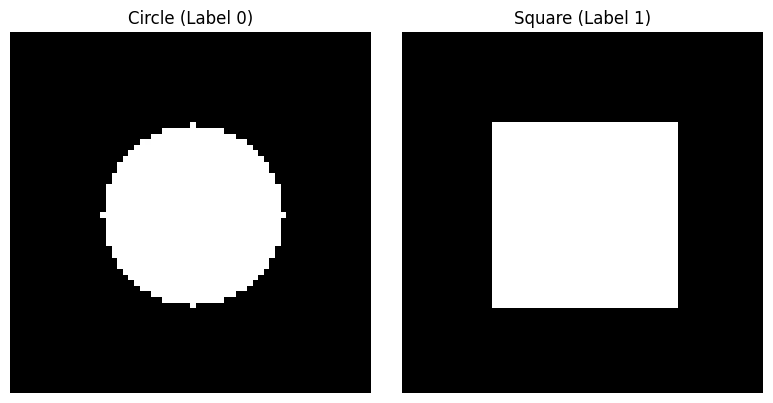

In [ ]:
noise = tf.random.normal(
    [2, LATENT_DIM]
)

labels = tf.constant(
    [[0], [1]],
    dtype=tf.int32
)

generated = generator(
    [noise, labels],
    training=False
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(8, 4)
)

axes[0].imshow(
    generated[0, :, :, 0],
    cmap="gray"
)

axes[0].set_title(
    "Circle (Label 0)"
)

axes[0].axis("off")

axes[1].imshow(
    generated[1, :, :, 0],
    cmap="gray"
)

axes[1].set_title(
    "Square (Label 1)"
)

axes[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
generator.save(
    "/content/cgan_generator.keras"
)

discriminator.save(
    "/content/cgan_discriminator.keras"
)

print("Models saved successfully")

Models saved successfully


In [ ]:
from PIL import Image
import os

num_images = 8

noise = tf.random.normal(
    [num_images, LATENT_DIM]
)

labels = tf.constant(
    [[0], [0], [0], [0],
     [1], [1], [1], [1]],
    dtype=tf.int32
)

generated = generator(
    [noise, labels],
    training=False
)

output_dir = "/content/cgan_outputs"

os.makedirs(
    output_dir,
    exist_ok=True
)

for i in range(num_images):

    img = (
        generated[i, :, :, 0].numpy() * 255
    ).astype("uint8")

    Image.fromarray(img).save(
        os.path.join(
            output_dir,
            f"generated_{i+1}.png"
        )
    )

print("Images saved in:", output_dir)

Images saved in: /content/cgan_outputs


In [ ]:
def generate_shape(label_text):

    label_map = {
        "circle": 0,
        "square": 1
    }

    label_text = label_text.lower().strip()

    if label_text not in label_map:
        raise ValueError("Use 'circle' or 'square'")

    noise = tf.random.normal(
        [1, LATENT_DIM]
    )

    label = tf.constant(
        [[label_map[label_text]]],
        dtype=tf.int32
    )

    generated = generator(
        [noise, label],
        training=False
    )

    image = generated[0, :, :, 0].numpy()

    return image

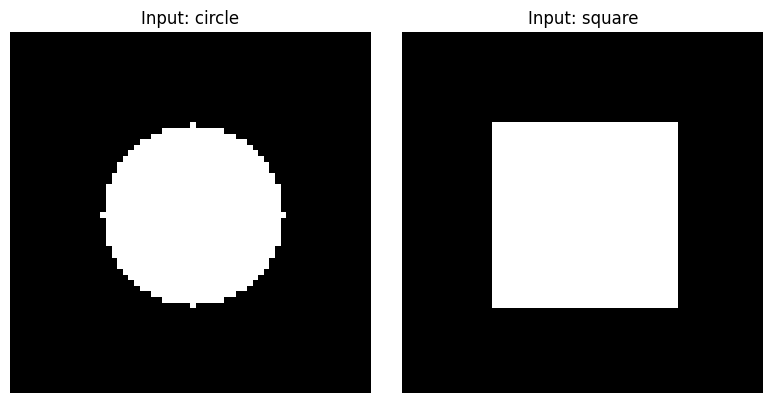

In [ ]:
circle_image = generate_shape("circle")
square_image = generate_shape("square")

fig, axes = plt.subplots(
    1, 2,
    figsize=(8, 4)
)

axes[0].imshow(
    circle_image,
    cmap="gray"
)

axes[0].set_title(
    "Input: circle"
)

axes[0].axis("off")

axes[1].imshow(
    square_image,
    cmap="gray"
)

axes[1].set_title(
    "Input: square"
)

axes[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Standalone Gradio launch disabled.
# The project is launched once in the final combined Gradio app (Task 1-6).


In [ ]:
generator.save(
    "/content/cgan_generator.keras"
)

discriminator.save(
    "/content/cgan_discriminator.keras"
)

print("Generator saved")
print("Discriminator saved")

Generator saved
Discriminator saved


# TASK **3**

In [ ]:
!pip install -q transformers gradio

In [ ]:
import torch
from transformers import CLIPTokenizer, CLIPTextModel

MODEL_ID = "stable-diffusion-v1-5/stable-diffusion-v1-5"

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = CLIPTokenizer.from_pretrained(
    MODEL_ID,
    subfolder="tokenizer"
)

text_encoder = CLIPTextModel.from_pretrained(
    MODEL_ID,
    subfolder="text_encoder"
).to(device)

text_encoder.eval()

print("Device:", device)
print("SD 1.5 text tokenizer and encoder loaded")

In [ ]:
text = "a beautiful futuristic city at sunset"

tokens = tokenizer(
    text,
    padding="max_length",
    max_length=77,
    truncation=True,
    return_tensors="pt"
)

input_ids = tokens["input_ids"].to(device)
attention_mask = tokens["attention_mask"].to(device)

with torch.no_grad():
    text_outputs = text_encoder(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

prompt_embeds = text_outputs.last_hidden_state

print("Text:", text)
print("Token shape:", input_ids.shape)
print("Embedding shape:", prompt_embeds.shape)

Text: a beautiful futuristic city at sunset
Token shape: torch.Size([1, 77])
Embedding shape: torch.Size([1, 77, 768])


In [ ]:
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    safety_checker=None
).to(device)

print("Stable Diffusion loaded")

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Stable Diffusion loaded


In [ ]:
negative_text = "blurry, low quality, distorted"

negative_tokens = tokenizer(
    negative_text,
    padding="max_length",
    max_length=77,
    truncation=True,
    return_tensors="pt"
)

negative_input_ids = negative_tokens["input_ids"].to(device)
negative_attention_mask = negative_tokens["attention_mask"].to(device)

with torch.no_grad():
    negative_outputs = text_encoder(
        input_ids=negative_input_ids,
        attention_mask=negative_attention_mask
    )

negative_prompt_embeds = negative_outputs.last_hidden_state

print(
    "Negative embedding shape:",
    negative_prompt_embeds.shape
)

Negative embedding shape: torch.Size([1, 77, 768])


  0%|          | 0/25 [00:00<?, ?it/s]

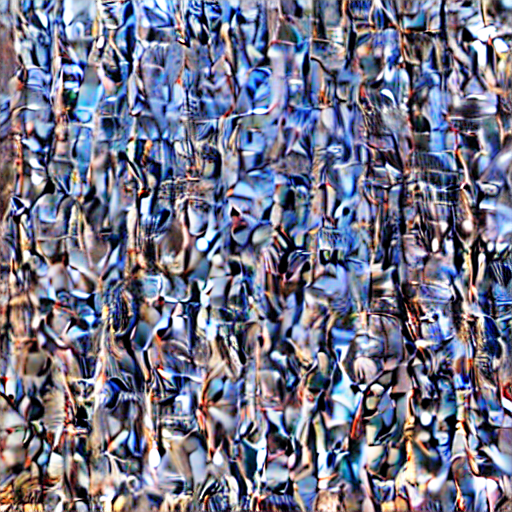

Image generated successfully


In [ ]:
image = pipe(
    prompt_embeds=prompt_embeds,
    negative_prompt_embeds=negative_prompt_embeds,
    num_inference_steps=25,
    guidance_scale=7.5,
    height=512,
    width=512
).images[0]

display(image)

image.save(
    "/content/task3_generated_image.png"
)

print("Image generated successfully")

# TASK 4

In [ ]:
!pip install -q datasets pandas matplotlib pillow

In [ ]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

dataset = load_dataset(
    "phiyodr/coco2017",
    split="validation",
    streaming=True
)

print(dataset)

README.md:   0%|          | 0.00/2.71k [00:00<?, ?B/s]

IterableDataset({
    features: ['license', 'file_name', 'coco_url', 'height', 'width', 'date_captured', 'flickr_url', 'image_id', 'ids', 'captions'],
    num_shards: 1
})


In [ ]:
samples = []

for i, item in enumerate(dataset):
    samples.append(item)

    if i >= 99:
        break

print("Samples loaded:", len(samples))
print(samples[0].keys())

Samples loaded: 100
dict_keys(['license', 'file_name', 'coco_url', 'height', 'width', 'date_captured', 'flickr_url', 'image_id', 'ids', 'captions'])


In [ ]:
for key, value in samples[0].items():
    print(key, ":", value)

license : 4
file_name : val2017/000000397133.jpg
coco_url : http://images.cocodataset.org/val2017/000000397133.jpg
height : 427
width : 640
date_captured : 2013-11-14 17:02:52
flickr_url : http://farm7.staticflickr.com/6116/6255196340_da26cf2c9e_z.jpg
image_id : 397133
ids : [370509, 370584, 372252, 372765, 375891]
captions : ['A man is in a kitchen making pizzas.', 'Man in apron standing on front of oven with pans and bakeware', 'A baker is working in the kitchen rolling dough.', 'A person standing by a stove in a kitchen.', 'A table with pies being made and a person standing near a wall with pots and pans hanging on the wall.']


In [ ]:
records = []

for item in samples:

    captions = item["captions"]

    if isinstance(captions, list):
        caption = captions[0]
    else:
        caption = str(captions)

    width = int(item["width"])
    height = int(item["height"])

    records.append({
        "caption": caption,
        "width": width,
        "height": height,
        "resolution": width * height,
        "caption_length_words": len(caption.split())
    })

df = pd.DataFrame(records)

print(df.head())

                                             caption  width  height  \
0               A man is in a kitchen making pizzas.    640     427   
1  The dining table near the kitchen has a bowl o...    352     230   
2    a person with a shopping cart on a city street     640     428   
3  A person on a skateboard and bike at a skate p...    640     480   
4                 a blue bike parked on a side walk     640     388   

   resolution  caption_length_words  
0      273280                     8  
1       80960                    13  
2      273920                    10  
3      307200                    11  
4      248320                     8  


In [ ]:
print("Samples analyzed:", len(df))

print(
    "COCO object categories:",
    80
)

print(
    "Average caption length:",
    round(df["caption_length_words"].mean(), 2),
    "words"
)

print(
    "Minimum caption length:",
    df["caption_length_words"].min(),
    "words"
)

print(
    "Maximum caption length:",
    df["caption_length_words"].max(),
    "words"
)

print(
    "Average width:",
    round(df["width"].mean(), 2),
    "pixels"
)

print(
    "Average height:",
    round(df["height"].mean(), 2),
    "pixels"
)

print(
    "Average resolution:",
    round(df["resolution"].mean())
)

Samples analyzed: 100
COCO object categories: 80
Average caption length: 10.31 words
Minimum caption length: 8 words
Maximum caption length: 21 words
Average width: 585.34 pixels
Average height: 472.86 pixels
Average resolution: 274032


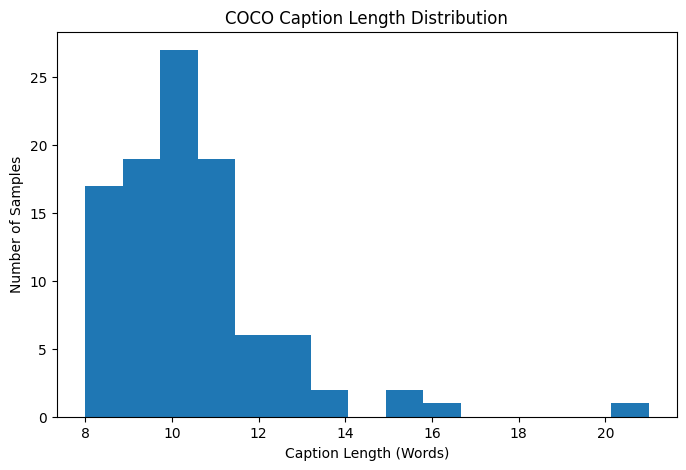

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["caption_length_words"],
    bins=15
)

plt.xlabel("Caption Length (Words)")
plt.ylabel("Number of Samples")
plt.title("COCO Caption Length Distribution")

plt.show()

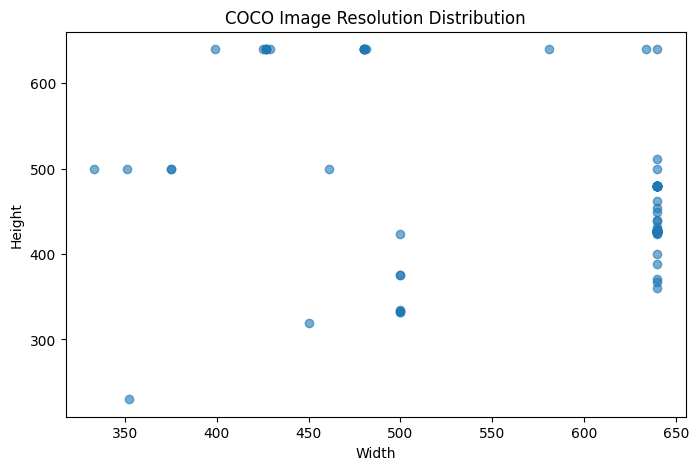

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["width"],
    df["height"],
    alpha=0.6
)

plt.xlabel("Width")
plt.ylabel("Height")
plt.title("COCO Image Resolution Distribution")

plt.show()

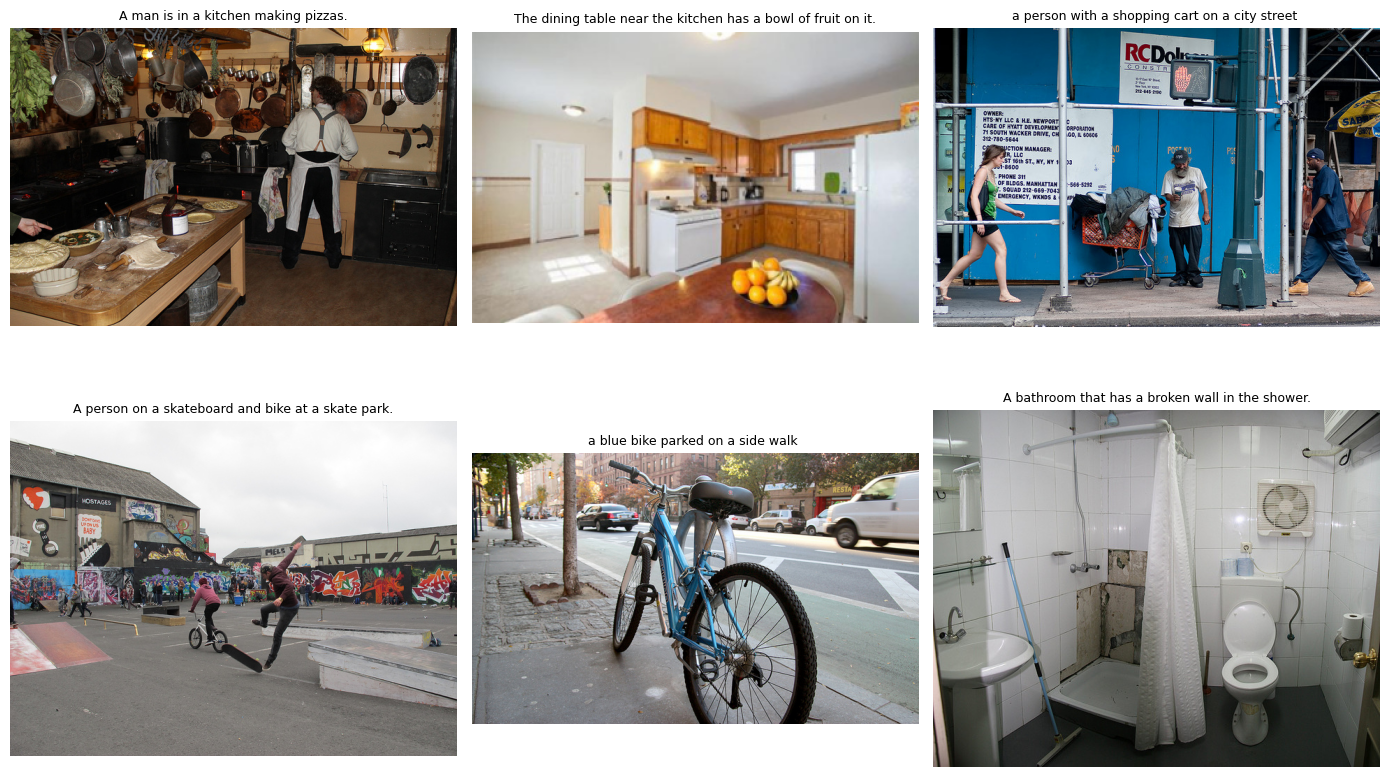

In [ ]:
import requests
from io import BytesIO
from PIL import Image

fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 9)
)

for ax, item in zip(
    axes.flat,
    samples[:6]
):

    try:

        response = requests.get(
            item["coco_url"],
            timeout=15
        )

        image = Image.open(
            BytesIO(response.content)
        ).convert("RGB")

        captions = item["captions"]

        if isinstance(captions, list):
            caption = captions[0]
        else:
            caption = str(captions)

        ax.imshow(image)

        ax.set_title(
            caption,
            fontsize=9
        )

        ax.axis("off")

    except Exception as e:

        ax.text(
            0.5,
            0.5,
            f"Image loading failed:\n{e}",
            ha="center",
            va="center"
        )

        ax.axis("off")

plt.tight_layout()
plt.show()

# TASK 5

In [79]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np
import matplotlib.pyplot as plt
from transformers import CLIPTokenizer, CLIPTextModel
import torch
import gradio as gr

print(f"TensorFlow Version: {tf.__version__}")
print(f"PyTorch Version: {torch.__version__}")
print("Environment setup complete")

TensorFlow Version: 2.20.0
PyTorch Version: 2.11.0+cu128
Environment setup complete


In [80]:
# Model Configuration
IMG_SIZE = 64
LATENT_DIM = 100
NUM_CLASSES = 2
BATCH_SIZE = 16
EPOCHS = 50
LEARNING_RATE = 0.0002
BETA_1 = 0.5

# Text Embedding Configuration
MAX_TEXT_LENGTH = 77
TEXT_EMBEDDING_DIM = 768

print("Configuration loaded successfully")
print(f"Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Latent Dimension: {LATENT_DIM}")
print(f"Number of Classes: {NUM_CLASSES}")

Configuration loaded successfully
Image Size: 64x64
Latent Dimension: 100
Number of Classes: 2


In [94]:
class SelfAttention(layers.Layer):
    """
    Memory-efficient Self-Attention mechanism.
    Uses channel reduction to prevent OOM errors.
    """
    def __init__(self, channels, reduction_ratio=4):
        super(SelfAttention, self).__init__()
        self.channels = channels
        self.reduced_channels = max(channels // reduction_ratio, 8)

        self.query_conv = layers.Conv2D(self.reduced_channels, kernel_size=1)
        self.key_conv = layers.Conv2D(self.reduced_channels, kernel_size=1)
        self.value_conv = layers.Conv2D(channels, kernel_size=1)
        self.gamma = tf.Variable(initial_value=0.0, trainable=True, name='attention_gamma')

    def call(self, x, training=None):
        batch_size = tf.shape(x)[0]
        height = tf.shape(x)[1]
        width = tf.shape(x)[2]
        channels = tf.shape(x)[3]

        # Generate query, key, value with reduced dimensions
        query = self.query_conv(x)
        key = self.key_conv(x)
        value = self.value_conv(x)

        # Reshape for attention computation
        query = tf.reshape(query, (batch_size, height * width, self.reduced_channels))
        key = tf.reshape(key, (batch_size, height * width, self.reduced_channels))
        value = tf.reshape(value, (batch_size, height * width, channels))

        # Compute attention scores with reduced memory
        attention_scores = tf.matmul(query, key, transpose_b=True)
        attention_scores = attention_scores / tf.sqrt(tf.cast(self.reduced_channels, tf.float32))
        attention_weights = tf.nn.softmax(attention_scores, axis=-1)

        # Apply attention to values
        attention_output = tf.matmul(attention_weights, value)
        attention_output = tf.reshape(attention_output, (batch_size, height, width, channels))

        # Residual connection with learnable scaling
        return self.gamma * attention_output + x

print("Memory-efficient SelfAttention layer implemented")

Memory-efficient SelfAttention layer implemented


In [95]:
class CrossAttention(layers.Layer):
    """
    Memory-efficient Cross-Attention mechanism.
    Uses reduced dimensions for attention computation.
    """
    def __init__(self, channels, text_dim, reduction_ratio=4):
        super(CrossAttention, self).__init__()
        self.channels = channels
        self.text_dim = text_dim
        self.reduced_channels = max(channels // reduction_ratio, 8)

        self.query_conv = layers.Conv2D(self.reduced_channels, kernel_size=1)
        self.key_dense = layers.Dense(self.reduced_channels)
        self.value_dense = layers.Dense(channels)
        self.gamma = tf.Variable(initial_value=0.0, trainable=True, name='cross_attention_gamma')

    def call(self, x, text_embeddings, training=None):
        batch_size = tf.shape(x)[0]
        height = tf.shape(x)[1]
        width = tf.shape(x)[2]
        channels = tf.shape(x)[3]

        # Generate query from image features
        query = self.query_conv(x)
        query = tf.reshape(query, (batch_size, height * width, self.reduced_channels))

        # Generate key and value from text embeddings
        key = self.key_dense(text_embeddings)
        value = self.value_dense(text_embeddings)

        # Compute cross-attention scores
        attention_scores = tf.matmul(query, key, transpose_b=True)
        attention_scores = attention_scores / tf.sqrt(tf.cast(self.reduced_channels, tf.float32))
        attention_weights = tf.nn.softmax(attention_scores, axis=-1)

        # Apply attention to text values
        attention_output = tf.matmul(attention_weights, value)
        attention_output = tf.reshape(attention_output, (batch_size, height, width, channels))

        # Residual connection with learnable scaling
        return self.gamma * attention_output + x

print("Memory-efficient CrossAttention layer implemented")

Memory-efficient CrossAttention layer implemented


In [96]:
def build_cross_attention_generator():
    """
    Generator with memory-efficient attention mechanisms.
    """
    # Input layers
    noise_input = layers.Input(shape=(LATENT_DIM,), name="noise_input")
    label_input = layers.Input(shape=(1,), dtype=tf.int32, name="label_input")
    text_input = layers.Input(shape=(MAX_TEXT_LENGTH, TEXT_EMBEDDING_DIM), name="text_input")

    # Label embedding
    label_embedding = layers.Embedding(NUM_CLASSES, 50, name="label_embedding")(label_input)
    label_embedding = layers.Flatten()(label_embedding)

    # Concatenate noise and label
    x = layers.Concatenate()([noise_input, label_embedding])

    # Initial dense layer
    x = layers.Dense(8 * 8 * 128, use_bias=False)(x)
    x = layers.Reshape((8, 8, 128))(x)

    # Upsampling block 1 - 8x8 to 16x16
    x = layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    # Upsampling block 2 - 16x16 to 32x32
    x = layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    # Cross-attention with text embeddings at 32x32
    x = CrossAttention(64, TEXT_EMBEDDING_DIM, reduction_ratio=8)(x, text_input)

    # Self-attention for spatial refinement
    x = SelfAttention(64, reduction_ratio=8)(x)

    # Upsampling block 3 - 32x32 to 64x64
    x = layers.Conv2DTranspose(32, kernel_size=4, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    # Output layer
    output = layers.Conv2D(1, kernel_size=4, padding='same', activation='tanh', name="generated_image")(x)

    model = Model([noise_input, label_input, text_input], output, name="CrossAttention_Generator")
    return model

# Instantiate generator
cross_attention_generator = build_cross_attention_generator()
print("Memory-efficient Generator Architecture:")
cross_attention_generator.summary()

Memory-efficient Generator Architecture:


Model: "CrossAttention_Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ label_embedding     │ (None, 1, 50)     │        100 │ label_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise_input         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 50)        │          0 │ label_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 150)       │          0 │ noise_input[0][0… │
│ (Concatenate)       │                   │            │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 8192)      │  1,228,800 │ concatenate_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_12          │ (None, 8, 8, 128) │          0 │ dense_21[0][0]    │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_12 │ (None, 16, 16,    │    262,144 │ reshape_12[0][0]  │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_20      │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_13 │ (None, 32, 32,    │    131,072 │ leaky_re_lu_20[0… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_21      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_input          │ (None, 77, 768)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cross_attention_4   │ (None, 32, 32,    │     55,888 │ leaky_re_lu_21[0… │
│ (CrossAttention)    │ 64)               │            │ text_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention_2    │ (None, 32, 32,    │      5,200 │ cross_attention_… │
│ (SelfAttention)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_14 │ (None, 64, 64,    │     32,768 │ self_attention_2… │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,717,381 (6.55 MB)

 Trainable params: 1,716,933 (6.55 MB)

 Non-trainable params: 448 (1.75 KB)

In [97]:
def build_attention_discriminator():
    """
    Discriminator with memory-efficient Self-Attention.
    """
    # Input layers
    image_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1), name="image_input")
    label_input = layers.Input(shape=(1,), dtype=tf.int32, name="label_input")

    # Label embedding and reshape
    label_embedding = layers.Embedding(NUM_CLASSES, IMG_SIZE * IMG_SIZE, name="discriminator_label_embedding")(label_input)
    label_embedding = layers.Flatten()(label_embedding)
    label_embedding = layers.Reshape((IMG_SIZE, IMG_SIZE, 1))(label_embedding)

    # Concatenate image and label
    x = layers.Concatenate()([image_input, label_embedding])

    # Convolutional block 1 - 64x64 to 32x32
    x = layers.Conv2D(32, kernel_size=4, strides=2, padding='same')(x)
    x = layers.LeakyReLU(0.2)(x)

    # Convolutional block 2 - 32x32 to 16x16
    x = layers.Conv2D(64, kernel_size=4, strides=2, padding='same')(x)
    x = layers.LeakyReLU(0.2)(x)

    # Self-attention at 16x16
    x = SelfAttention(64, reduction_ratio=8)(x)

    # Convolutional block 3 - 16x16 to 8x8
    x = layers.Conv2D(128, kernel_size=4, strides=2, padding='same')(x)
    x = layers.LeakyReLU(0.2)(x)

    # Classification head
    x = layers.Flatten()(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(1, activation='sigmoid', name="validity")(x)

    model = Model([image_input, label_input], output, name="Attention_Discriminator")
    return model

# Instantiate discriminator
attention_discriminator = build_attention_discriminator()
print("Memory-efficient Discriminator Architecture:")
attention_discriminator.summary()

Memory-efficient Discriminator Architecture:


Model: "Attention_Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ discriminator_labe… │ (None, 1, 4096)   │      8,192 │ label_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_6 (Flatten) │ (None, 4096)      │          0 │ discriminator_la… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_input         │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_13          │ (None, 64, 64, 1) │          0 │ flatten_6[0][0]   │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 64, 64, 2) │          0 │ image_input[0][0… │
│ (Concatenate)       │                   │            │ reshape_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 32, 32,    │      1,056 │ concatenate_7[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_23      │ (None, 32, 32,    │          0 │ conv2d_24[0][0]   │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 16, 16,    │     32,832 │ leaky_re_lu_23[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_24      │ (None, 16, 16,    │          0 │ conv2d_25[0][0]   │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention_3    │ (None, 16, 16,    │      5,200 │ leaky_re_lu_24[0… │
│ (SelfAttention)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 8, 8, 128) │    131,200 │ self_attention_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_25      │ (None, 8, 8, 128) │          0 │ conv2d_29[0][0]   │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 8192)      │          0 │ leaky_re_lu_25[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 8192)      │          0 │ flatten_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ validity (Dense)    │ (None, 1)         │      8,193 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 186,673 (729.19 KB)

 Trainable params: 186,673 (729.19 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
class TextEmbeddingProcessor:
    """
    Text embedding processor using CLIP text encoder.
    Converts text descriptions to embeddings for conditioning.
    """
    def __init__(self, model_id="stable-diffusion-v1-5/stable-diffusion-v1-5"):
        self.tokenizer = CLIPTokenizer.from_pretrained(model_id, subfolder="tokenizer")
        self.text_encoder = CLIPTextModel.from_pretrained(model_id, subfolder="text_encoder")
        self.text_encoder.eval()

    def get_embedding(self, text):
        """Generate text embedding for a single text input."""
        inputs = self.tokenizer(
            text,
            return_tensors="pt",
            padding="max_length",
            max_length=MAX_TEXT_LENGTH,
            truncation=True
        )
        with torch.no_grad():
            embeddings = self.text_encoder(inputs.input_ids).last_hidden_state
        return embeddings.numpy()

    def get_batch_embeddings(self, labels):
        """Generate batch text embeddings based on labels."""
        embeddings = []
        for label in labels.numpy():
            if label == 0:
                emb = self.circle_embedding[0]
            else:
                emb = self.square_embedding[0]
            embeddings.append(emb)
        return tf.convert_to_tensor(np.array(embeddings), dtype=tf.float32)

# Initialize text embedding processor
text_processor = TextEmbeddingProcessor()

# Pre-compute embeddings for classes
text_processor.circle_embedding = text_processor.get_embedding("a perfect circle shape")
text_processor.square_embedding = text_processor.get_embedding("a perfect square shape")

print(f"Circle embedding shape: {text_processor.circle_embedding.shape}")
print(f"Square embedding shape: {text_processor.square_embedding.shape}")
print("Text embedding pipeline ready")

In [98]:
# Loss function
cross_entropy_loss = tf.keras.losses.BinaryCrossentropy(from_logits=False)

# Optimizers
generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE,
    beta_1=BETA_1
)
discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE,
    beta_1=BETA_1
)

# Pre-compute text embeddings as constants
circle_embedding_tensor = tf.constant(text_processor.circle_embedding[0], dtype=tf.float32)
square_embedding_tensor = tf.constant(text_processor.square_embedding[0], dtype=tf.float32)

@tf.function
def cross_attention_train_step(real_images, real_labels):
    """
    Single training step for cross-attention CGAN with memory optimization.
    """
    batch_size = tf.shape(real_images)[0]
    noise = tf.random.normal([batch_size, LATENT_DIM])

    # Create text embeddings using tf.gather
    label_indices = tf.reshape(real_labels, [-1])

    # Stack embeddings for both classes
    all_embeddings = tf.stack([circle_embedding_tensor, square_embedding_tensor], axis=0)

    # Gather embeddings based on labels
    text_embeddings = tf.gather(all_embeddings, label_indices)

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # Generate fake images
        fake_images = cross_attention_generator(
            [noise, real_labels, text_embeddings],
            training=True
        )

        # Discriminator predictions
        real_output = attention_discriminator([real_images, real_labels], training=True)
        fake_output = attention_discriminator([fake_images, real_labels], training=True)

        # Calculate losses
        generator_loss = cross_entropy_loss(tf.ones_like(fake_output), fake_output)
        discriminator_loss = cross_entropy_loss(tf.ones_like(real_output), real_output) + \
                            cross_entropy_loss(tf.zeros_like(fake_output), fake_output)

    # Compute gradients
    generator_gradients = gen_tape.gradient(
        generator_loss,
        cross_attention_generator.trainable_variables
    )
    discriminator_gradients = disc_tape.gradient(
        discriminator_loss,
        attention_discriminator.trainable_variables
    )

    # Apply gradients
    generator_optimizer.apply_gradients(
        zip(generator_gradients, cross_attention_generator.trainable_variables)
    )
    discriminator_optimizer.apply_gradients(
        zip(discriminator_gradients, attention_discriminator.trainable_variables)
    )

    return generator_loss, discriminator_loss

print("Memory-efficient training configuration ready")

Memory-efficient training configuration ready


In [ ]:
def train_cross_attention_gan(dataset, epochs=EPOCHS):
    """
    Training loop for cross-attention CGAN.
    """
    print("Starting Cross-Attention CGAN Training...")
    print(f"Total Epochs: {epochs}")

    training_history = {
        'generator_loss': [],
        'discriminator_loss': []
    }

    for epoch in range(epochs):
        epoch_gen_losses = []
        epoch_disc_losses = []

        for batch_idx, (real_images, real_labels) in enumerate(dataset):
            gen_loss, disc_loss = cross_attention_train_step(real_images, real_labels)
            epoch_gen_losses.append(float(gen_loss))
            epoch_disc_losses.append(float(disc_loss))

        avg_gen_loss = np.mean(epoch_gen_losses)
        avg_disc_loss = np.mean(epoch_disc_losses)

        training_history['generator_loss'].append(avg_gen_loss)
        training_history['discriminator_loss'].append(avg_disc_loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Generator Loss: {avg_gen_loss:.4f} | Discriminator Loss: {avg_disc_loss:.4f}")

    # Save models
    cross_attention_generator.save('/content/cross_attention_generator.keras')
    attention_discriminator.save('/content/attention_discriminator.keras')

    print("Training completed. Models saved successfully.")
    return training_history

# Rebuild the circle/square dataset here under its own name, using Task 5's
# BATCH_SIZE (16). This used to just reuse the global `dataset`, but by this
# point in the notebook `dataset` had been reassigned by the Task 4 section
# (COCO captions) to a completely different (non image/label) dataset, which
# made this training loop crash with "too many values to unpack". X and y
# (the circle/square samples from Task 2) are untouched, so we rebuild from
# them directly and pass that in, instead of relying on the global name.
shapes_dataset = (
    tf.data.Dataset.from_tensor_slices((X, y))
    .shuffle(len(X))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Execute training
history = train_cross_attention_gan(shapes_dataset, epochs=EPOCHS)

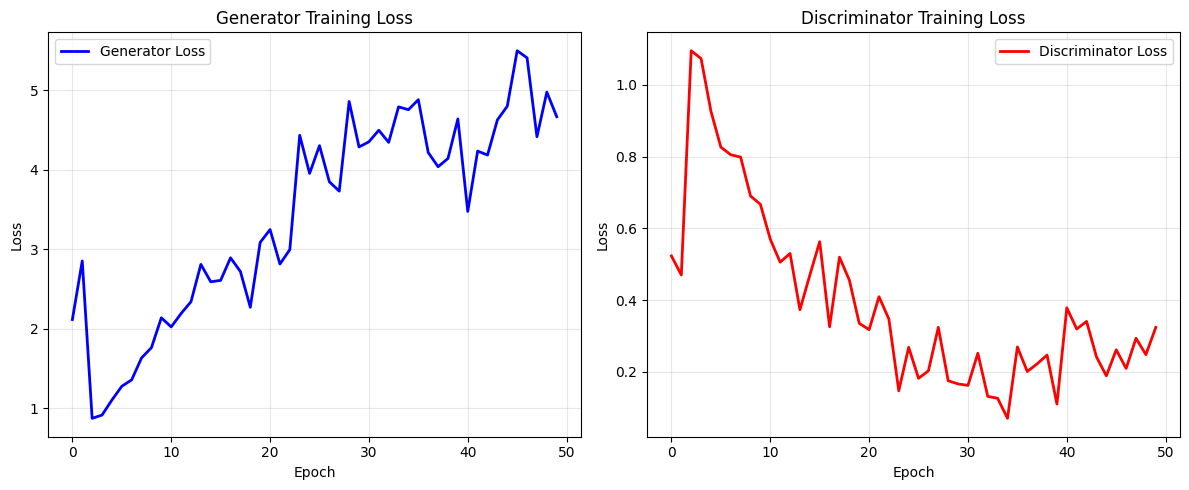

Training loss curves saved successfully


In [100]:
# Plot training losses
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['generator_loss'], label='Generator Loss', color='blue', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Generator Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['discriminator_loss'], label='Discriminator Loss', color='red', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Discriminator Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/task5_training_losses.png', dpi=150, bbox_inches='tight')
plt.show()

print("Training loss curves saved successfully")

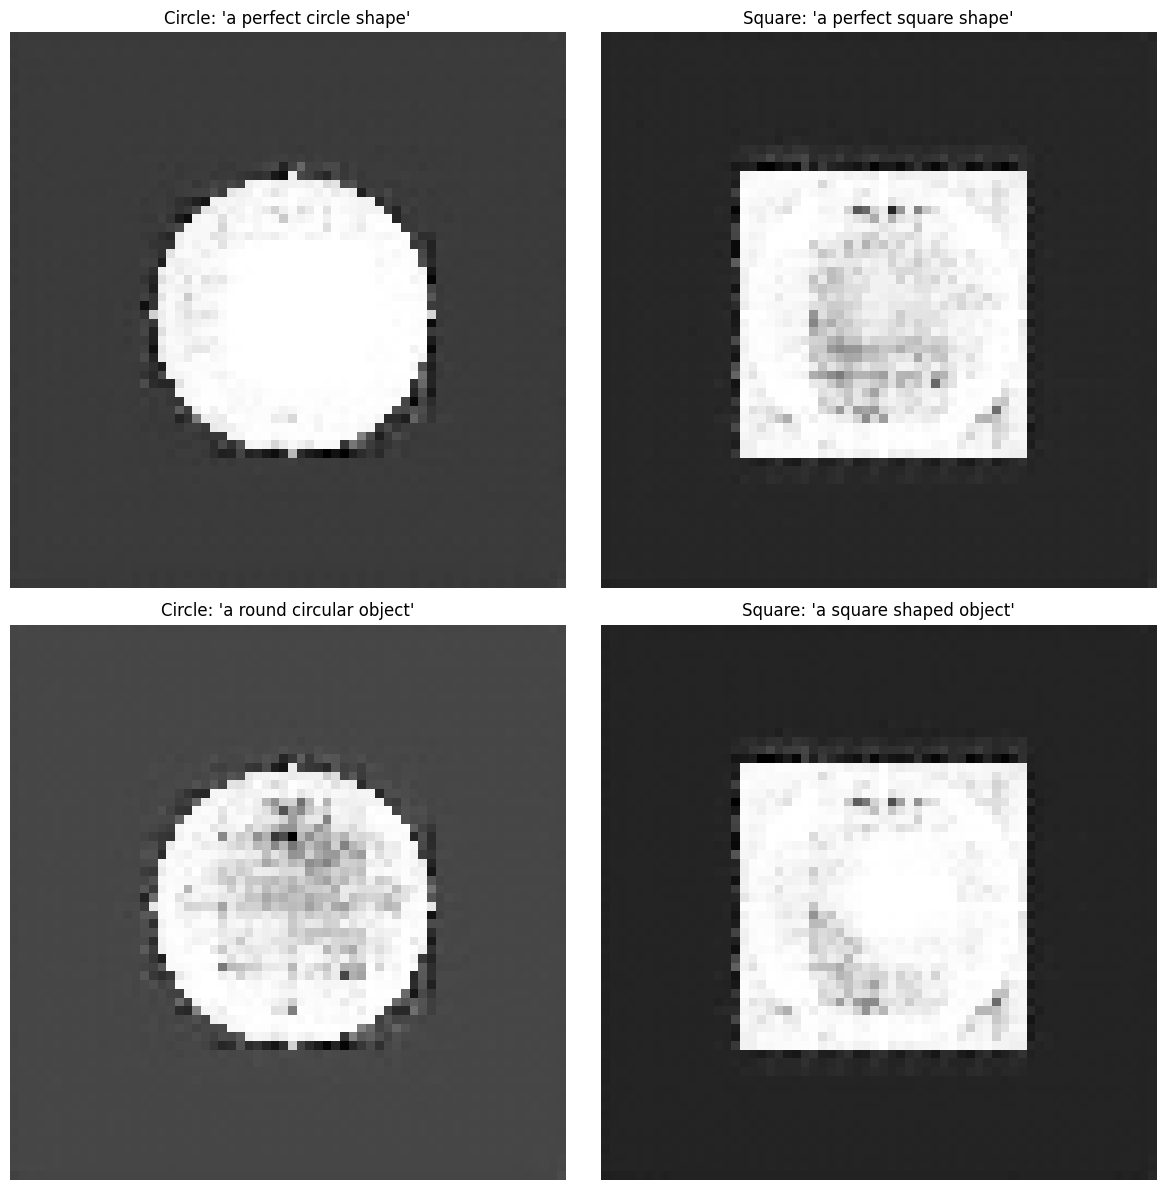

Sample images generated and saved successfully


In [101]:
def generate_cross_attention_image(label, text_prompt):
    """
    Generate image using cross-attention generator.
    """
    noise = tf.random.normal([1, LATENT_DIM])
    label_tensor = tf.constant([label], dtype=tf.int32)

    text_embedding = text_processor.get_embedding(text_prompt)
    text_tensor = tf.convert_to_tensor(text_embedding, dtype=tf.float32)

    generated_image = cross_attention_generator(
        [noise, label_tensor, text_tensor],
        training=False
    )
    generated_image = (generated_image.numpy()[0, :, :, 0] + 1) / 2.0

    return generated_image

# Generate multiple samples for comparison
circle_image = generate_cross_attention_image(0, "a perfect circle shape")
square_image = generate_cross_attention_image(1, "a perfect square shape")
circle_image_2 = generate_cross_attention_image(0, "a round circular object")
square_image_2 = generate_cross_attention_image(1, "a square shaped object")

# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0, 0].imshow(circle_image, cmap='gray')
axes[0, 0].set_title("Circle: 'a perfect circle shape'", fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(square_image, cmap='gray')
axes[0, 1].set_title("Square: 'a perfect square shape'", fontsize=12)
axes[0, 1].axis('off')

axes[1, 0].imshow(circle_image_2, cmap='gray')
axes[1, 0].set_title("Circle: 'a round circular object'", fontsize=12)
axes[1, 0].axis('off')

axes[1, 1].imshow(square_image_2, cmap='gray')
axes[1, 1].set_title("Square: 'a square shaped object'", fontsize=12)
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('/content/task5_cross_attention_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("Sample images generated and saved successfully")

# TASK 6 — Comprehensive Text-to-Image Generating Pipeline

This task integrates GAN-based image generation, text preprocessing, and text embedding creation into one end-to-end pipeline.

**Pipeline:** Text Prompt → Preprocessing → CLIP Text Embedding → Noise + Shape Condition → Cross-Attention GAN → Generated Image

In [ ]:
# ============================================================
# TASK 6 - COMPLETE TEXT-TO-IMAGE GENERATING PIPELINE
# ============================================================

import re
import numpy as np
import tensorflow as tf

# Safe dependency setup
if 'LATENT_DIM' not in globals():
    try:
        LATENT_DIM = int(cross_attention_generator.input_shape[0][-1])
    except Exception:
        LATENT_DIM = 100

if 'MAX_TEXT_LENGTH' not in globals():
    try:
        MAX_TEXT_LENGTH = int(cross_attention_generator.input_shape[2][1])
    except Exception:
        MAX_TEXT_LENGTH = 77

if 'TEXT_EMBEDDING_DIM' not in globals():
    try:
        TEXT_EMBEDDING_DIM = int(cross_attention_generator.input_shape[2][2])
    except Exception:
        TEXT_EMBEDDING_DIM = 768

# Step 1: Text preprocessing
def preprocess_text_task6(text):
    if text is None:
        text = ""

    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^\w\s.,!?'-]", "", text)
    text = text.lower().strip()

    if not text:
        text = "a simple circular shape"

    return text

# Step 2: Text embedding creation
def create_text_embedding_task6(text):
    cleaned_text = preprocess_text_task6(text)

    if 'text_processor' not in globals():
        raise RuntimeError(
            "Task 5 text_processor is not initialized. "
            "Run the Task 5 text-embedding cell first."
        )

    embedding = text_processor.get_embedding(cleaned_text)
    embedding = np.asarray(embedding, dtype=np.float32)

    # Expected by the Cross-Attention Generator:
    # (batch, 77, 768)
    if embedding.ndim == 2:
        embedding = embedding[np.newaxis, ...]

    return cleaned_text, embedding

# Step 3 + 4: Condition selection + GAN generation
def generate_gan_from_text_task6(text, shape_hint=None, seed=None):
    if 'cross_attention_generator' not in globals():
        raise RuntimeError(
            "Task 5 Cross-Attention Generator is not initialized. "
            "Run the Task 5 model-building cells first."
        )

    cleaned_text, text_embedding = create_text_embedding_task6(text)
    prompt_lower = cleaned_text.lower()

    if shape_hint is not None:
        hint = str(shape_hint).lower().strip()
        if hint == "circle":
            label = 0
        elif hint == "square":
            label = 1
        else:
            raise ValueError("shape_hint must be 'circle' or 'square'.")
    elif any(word in prompt_lower for word in ["circle", "round", "circular"]):
        label = 0
    elif any(word in prompt_lower for word in ["square", "rectangle"]):
        label = 1
    else:
        label = 0

    if seed is None:
        seed = int(tf.random.uniform([], maxval=2**31 - 1, dtype=tf.int64))
    tf.random.set_seed(seed)

    noise = tf.random.normal([1, LATENT_DIM])
    label_tensor = tf.constant([label], dtype=tf.int32)
    text_tensor = tf.convert_to_tensor(text_embedding, dtype=tf.float32)

    generated = cross_attention_generator(
        [noise, label_tensor, text_tensor],
        training=False
    )

    image = (generated.numpy()[0, :, :, 0] + 1.0) / 2.0
    image = np.clip(image, 0.0, 1.0)

    pipeline_info = (
        "Text preprocessing: DONE\n"
        "Text embedding creation: DONE\n"
        f"Embedding shape: {tuple(text_embedding.shape)}\n"
        f"GAN condition label: {label} "
        f"({'circle' if label == 0 else 'square'})\n"
        f"Latent dimension: {LATENT_DIM}\n"
        f"Seed used: {seed}\n"
        "Generator: Cross-Attention GAN"
    )

    return image, cleaned_text, str(tuple(text_embedding.shape)), pipeline_info

# Quick test — does NOT train the model.
try:
    task6_test_image, task6_test_text, task6_test_embedding_shape, task6_test_info = (
        generate_gan_from_text_task6("a circular object")
    )
    print("TASK 6 PIPELINE READY")
    print(task6_test_info)
except Exception as e:
    print("TASK 6 FUNCTION READY")
    print("Quick test skipped:", str(e))


In [ ]:
def generate_shape_with_attention(prompt_text):
    """
    Cross-Attention GAN generation function for Task 5.
    """
    prompt_lower = prompt_text.lower()

    if "circle" in prompt_lower or "round" in prompt_lower or "circular" in prompt_lower:
        label = 0
    elif "square" in prompt_lower or "rectangle" in prompt_lower:
        label = 1
    else:
        label = np.random.randint(0, 2)

    noise = tf.random.normal([1, LATENT_DIM])
    label_tensor = tf.constant([label], dtype=tf.int32)

    text_embedding = text_processor.get_embedding(prompt_text)
    text_tensor = tf.convert_to_tensor(text_embedding, dtype=tf.float32)

    generated_image = cross_attention_generator(
        [noise, label_tensor, text_tensor],
        training=False
    )
    generated_image = (generated_image.numpy()[0, :, :, 0] + 1) / 2.0

    return generated_image

def generate_shape_basic(shape_type):
    """
    Basic CGAN generation function for Task 2.

    Fix: this previously referenced an undefined name `basic_generator`
    (NameError) and rescaled with the (+1)/2 formula meant for a tanh
    generator. Task 2's actual model is the `generator` built earlier in
    this notebook and already has a working, tested wrapper for exactly
    this purpose: `generate_shape()`. We reuse it here instead of
    duplicating/re-deriving the generation logic.
    """
    try:
        image = generate_shape(shape_type)
        image = (image * 255).astype(np.uint8)
        return Image.fromarray(image)
    except Exception as e:
        print(e)
        return None

def generate_stable_diffusion(prompt, use_lora=False):
    """
    Stable Diffusion generation for Task 1 and Task 3.
    """
    try:
        if use_lora and os.path.exists('/content/book_cover_lora/pytorch_lora_weights.safetensors'):
            pipe.load_lora_weights('/content/book_cover_lora')
            lora_status = "LoRA loaded"
        else:
            lora_status = "LoRA not available, using base model"

        # Generate image
        image = pipe(
            prompt=prompt,
            num_inference_steps=25,
            guidance_scale=7.5,
            height=512,
            width=512
        ).images[0]

        # Get text embeddings for display
        tokenized = pipe.tokenizer(prompt, return_tensors="pt", padding="max_length", max_length=77, truncation=True)
        tokenized_shape = str(tokenized.input_ids.shape)

        with torch.no_grad():
            embeddings = pipe.text_encoder(tokenized.input_ids).last_hidden_state
        embedding_shape = str(embeddings.shape)

        return image, tokenized_shape, embedding_shape, lora_status

    except Exception as e:
        return None, "Error", f"Error: {str(e)}", "Failed"

# Gallery state for Task 6, kept separately from Task 1's sd_ui.gallery_images
# so each tab's "Recent Images" only shows its own generations.
task6_gallery_images = []

def run_task6_pipeline(prompt, shape_hint_choice, seed, save_image):
    try:
        hint = None if shape_hint_choice == "Auto-detect from text" else shape_hint_choice
        actual_seed = None if int(seed) == -1 else int(seed)

        image, cleaned_text, embedding_shape, info = generate_gan_from_text_task6(
            prompt, shape_hint=hint, seed=actual_seed
        )

        pil_image = Image.fromarray((image * 255).astype(np.uint8))

        saved_path = ""
        if save_image:
            timestamp = int(time.time())
            saved_path = f"/content/task6_generated_{timestamp}.png"
            pil_image.save(saved_path)

        task6_gallery_images.append(pil_image)
        if len(task6_gallery_images) > 10:
            task6_gallery_images[:] = task6_gallery_images[-10:]

        return pil_image, cleaned_text, embedding_shape, info, saved_path, task6_gallery_images
    except Exception as e:
        return None, "Error", "Error", f"Task 6 Error: {str(e)}", "", task6_gallery_images

# Persistent state object for the Task 1 workflow (Model/Device init,
# holds the loaded StableDiffusionGenerator across button clicks).
sd_ui = StableDiffusionUI()

# Main Gradio App - Same Project
with gr.Blocks(title="AI Image Generation Project", theme=gr.themes.Soft(primary_hue="indigo", secondary_hue="blue")) as demo:
    gr.Markdown("# AI Image Generation Project")
    gr.Markdown("### Stable Diffusion + Conditional GAN + Cross-Attention GAN + Text-to-Image Pipeline")

    # Tab 1: Text-to-Image (Task 1) - full workflow, reusing the existing
    # StableDiffusionUI class (Model/Device selection, explicit Initialize
    # Model step with a Model Status readout, then generation with the
    # full settings panel). `sd_ui` is instantiated once, above, so its
    # internal state (the loaded model) persists across clicks.
    with gr.Tab("Text-to-Image (Task 1)"):
        gr.Markdown("### Stable Diffusion Image Generation")

        with gr.Row():
            with gr.Column():
                model_choice = gr.Dropdown(
                    choices=["Stable Diffusion 1.5"],
                    value="Stable Diffusion 1.5",
                    label="Model"
                )
                device_choice = gr.Dropdown(
                    choices=["Auto (Recommended)", "GPU (CUDA)", "CPU (Slower)"],
                    value="GPU (CUDA)",
                    label="Device"
                )
                initialize_btn = gr.Button("Initialize Model", variant="primary")
                status = gr.Textbox(label="Model Status", lines=4)

            with gr.Column():
                prompt_input = gr.Textbox(
                    label="Text Description",
                    value="a realistic mountain landscape at sunset",
                    placeholder="Describe the image you want to generate...",
                    lines=4
                )
                negative_prompt = gr.Textbox(
                    label="Negative Prompt",
                    value="blurry, low quality, distorted",
                    lines=2
                )

        with gr.Accordion("Generation Settings", open=False):
            width = gr.Slider(256, 1024, 512, step=64, label="Width")
            height = gr.Slider(256, 1024, 512, step=64, label="Height")
            steps = gr.Slider(10, 50, 25, step=1, label="Inference Steps")
            guidance = gr.Slider(1, 15, 7.5, step=0.5, label="Guidance Scale")
            scheduler = gr.Dropdown(
                choices=["euler_a", "euler", "ddim", "dpm_solver", "lms"],
                value="euler_a",
                label="Scheduler"
            )
            scheduler_info = gr.Textbox(label="Scheduler Information")
            seed = gr.Number(value=-1, label="Seed (-1 = Random)")
            save_image = gr.Checkbox(value=True, label="Save Image")

        generate_button = gr.Button("Generate Image", variant="primary")
        output_image = gr.Image(label="Generated Image", type="pil")
        generation_info = gr.Textbox(label="Generation Details", lines=10)
        save_path = gr.Textbox(label="Saved Image Path")
        gallery = gr.Gallery(label="Recent Images", columns=4, rows=2)

        initialize_btn.click(
            fn=sd_ui.initialize_generator,
            inputs=[model_choice, device_choice],
            outputs=status
        )

        scheduler.change(
            fn=sd_ui.show_scheduler_info,
            inputs=scheduler,
            outputs=scheduler_info
        )

        generate_button.click(
            fn=sd_ui.text_to_image,
            inputs=[
                prompt_input, negative_prompt, width, height,
                steps, guidance, seed, scheduler, save_image
            ],
            outputs=[output_image, generation_info, save_path, gallery]
        )

    # Tab 2: Conditional GAN - Basic (Task 2)
    with gr.Tab("Basic CGAN (Task 2)"):
        gr.Markdown("### Conditional GAN for Shape Generation")

        with gr.Row():
            with gr.Column():
                shape_input = gr.Radio(
                    choices=["circle", "square"],
                    label="Select Shape",
                    value="circle"
                )
                shape_generate_button = gr.Button("Generate Shape", variant="primary")

            with gr.Column():
                shape_output = gr.Image(label="Generated Shape")

        shape_generate_button.click(
            fn=generate_shape_basic,
            inputs=shape_input,
            outputs=shape_output
        )

    # Tab 3: Cross-Attention GAN (Task 5)
    with gr.Tab("Cross-Attention GAN (Task 5)"):
        gr.Markdown("### Cross-Attention GAN with Text Understanding")

        with gr.Row():
            with gr.Column():
                attention_prompt = gr.Textbox(
                    label="Describe Shape",
                    value="a perfect circle shape",
                    placeholder="Example: a perfect circle shape, a square shaped object"
                )
                attention_generate_button = gr.Button("Generate with Attention", variant="primary")

            with gr.Column():
                attention_output = gr.Image(label="Cross-Attention Output")

        attention_generate_button.click(
            fn=generate_shape_with_attention,
            inputs=attention_prompt,
            outputs=attention_output
        )

    # Tab 4: Text Embeddings (Task 3)
    with gr.Tab("Text Embeddings (Task 3)"):
        gr.Markdown("### Text Embedding Visualization")

        with gr.Row():
            with gr.Column():
                embedding_prompt = gr.Textbox(
                    label="Enter Text",
                    value="a circular object"
                )
                embedding_button = gr.Button("Generate Embeddings", variant="primary")

            with gr.Column():
                embedding_image_output = gr.Image(label="Generated from Embeddings")

        embedding_button.click(
            fn=lambda text: generate_stable_diffusion(text)[0],
            inputs=embedding_prompt,
            outputs=embedding_image_output
        )

    # Tab 5: Comprehensive Text-to-Image Pipeline (Task 6)
    with gr.Tab("Text-to-Image Pipeline (Task 6)"):
        gr.Markdown(
            "### Comprehensive Text-to-Image Generating Pipeline\n\n"
            "**Text Prompt → Text Preprocessing → CLIP Text Embedding → "
            "Noise + Shape Condition → Cross-Attention GAN → Generated Image**"
        )

        with gr.Row():
            with gr.Column():
                task6_prompt = gr.Textbox(
                    label="Enter Text Prompt",
                    value="a circular object",
                    placeholder="Example: a circular object or a square shaped object",
                    lines=3
                )
                task6_shape_hint = gr.Dropdown(
                    choices=["Auto-detect from text", "circle", "square"],
                    value="Auto-detect from text",
                    label="Shape Hint"
                )

                with gr.Accordion("Advanced Settings", open=False):
                    task6_seed = gr.Number(value=-1, label="Seed (-1 = Random)")
                    task6_save_image = gr.Checkbox(value=True, label="Save Image")

                task6_generate_button = gr.Button(
                    "Run Complete Pipeline",
                    variant="primary"
                )

            with gr.Column():
                task6_output_image = gr.Image(
                    label="Task 6 Generated Image",
                    type="pil"
                )

        task6_cleaned_text = gr.Textbox(
            label="Preprocessed Text"
        )
        task6_embedding_shape = gr.Textbox(
            label="Text Embedding Shape"
        )
        task6_info = gr.Textbox(
            label="Pipeline Information",
            lines=7
        )
        task6_save_path = gr.Textbox(
            label="Saved Image Path"
        )
        task6_gallery = gr.Gallery(
            label="Recent Task 6 Images",
            columns=4,
            rows=2
        )

        task6_generate_button.click(
            fn=run_task6_pipeline,
            inputs=[
                task6_prompt,
                task6_shape_hint,
                task6_seed,
                task6_save_image
            ],
            outputs=[
                task6_output_image,
                task6_cleaned_text,
                task6_embedding_shape,
                task6_info,
                task6_save_path,
                task6_gallery
            ]
        )

    # Tab 5: About Project
    with gr.Tab("About / Tasks"):
        gr.Markdown("""
        ## Project Overview

        This single project integrates multiple AI/Generative AI tasks:

        ### Task 1: Stable Diffusion with LoRA
        - Fine-tuned on British Library book covers
        - LoRA adaptation for efficient training
        - Conditional image generation

        ### Task 2: Conditional GAN
        - Generates shapes (circle/square) based on labels
        - Basic conditional generation
        - 64x64 grayscale images

        ### Task 3: Text Embeddings
        - CLIP tokenizer and text encoder
        - Converts text to embeddings (77×768)
        - Feeds embeddings to Stable Diffusion

        ### Task 4: Dataset Analysis
        - COCO 2017 dataset analysis
        - Caption length statistics
        - Image resolution analysis
        - Visualization of dataset

        ### Task 5: Cross-Attention GAN
        - Self-Attention mechanism
        - Cross-Attention for text conditioning
        - Improved image quality
        - Text understanding for generation

        ### Task 6: Comprehensive Text-to-Image Pipeline
        - Text preprocessing and normalization
        - CLIP text embedding creation
        - Shape-aware GAN conditioning
        - End-to-end Cross-Attention GAN generation

        ## Architecture

        This project demonstrates:
        1. **Text-to-Image Generation**: Stable Diffusion
        2. **Conditional Generation**: CGAN with labels
        3. **Attention Mechanisms**: Self and Cross attention
        4. **Text Understanding**: CLIP embeddings
        5. **Dataset Analysis**: Statistical analysis and visualization
        """)

demo.launch(share=True)